In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# ============================================================
# CONFIG
# ============================================================
PROJECT = Path("/user/ab5405/summeraliaclimate/code/energy_uncertainty")
REGD    = PROJECT / "data" / "regression"
STERD   = REGD / "sters"
OUTDIR  = PROJECT / "output" / "figures"
OUTDIR.mkdir(parents=True, exist_ok=True)

# choose fuel
FUEL = "electricity"          # "electricity" or "other_energy"
PG   = 1 if FUEL == "electricity" else 2

# IMPORTANT: choose the break_data file that actually exists in your pipeline
# (based on your Stata usage, it's usually break_data_TINV_clim.dta)
BREAK_DATA = "/user/ab5405/summeraliaclimate/code/energy_consumption/energy_data_release_2021oct21/DATA/regression/break_data_TINV_clim.dta"

# temperature grid (-5..35 inclusive like paper)
TMIN, TMAX = -5, 35
T = np.arange(TMIN, TMAX + 1, 1).astype(float)

ABOVE20 = (T >= 20).astype(float)
BELOW20 = (T < 20).astype(float)

# climate products you want overlaid
PRODUCTS = ["GMFD", "ERA5", "JRA_3Q", "MERRA2"]

# your exported regression outputsFD_FGLS_inter_TINV_clim_lininter_ERA5_coeff
COEF_PATH = {p: STERD / f"FD_FGLS_inter_TINV_clim_quadinter_{p}_coeff.csv" for p in PRODUCTS}
VCOV_PATH = {p: STERD / f"FD_FGLS_inter_TINV_clim_quadinter_{p}_vcov_long.csv" for p in PRODUCTS}

# MC settings (like mortality style)
N_DRAWS = 2000
SEED = 123
BAND_PCTS = (2.5, 97.5)

# plot style
COLOR = {"GMFD": "navy", "ERA5": "red", "JRA_3Q": "orange", "MERRA2": "black"}
ALPHA_BAND = 0.15
LW = 2.0

# ============================================================
# HELPERS: read coeff + vcov
# ============================================================
def read_coeff_series(path: Path) -> pd.Series:
    df = pd.read_csv(path)
    return pd.Series(df["beta"].values, index=df["parm"].astype(str).values)

def read_vcov_long(path: Path) -> pd.DataFrame:
    df = pd.read_csv(path)
    df["parm_i"] = df["parm_i"].astype(str)
    df["parm_j"] = df["parm_j"].astype(str)
    return df

def vcov_submatrix(vlong: pd.DataFrame, names: list[str]) -> np.ndarray:
    sub = vlong[vlong["parm_i"].isin(names) & vlong["parm_j"].isin(names)]
    if sub.shape[0] != len(names) * len(names):
        missing = set((i, j) for i in names for j in names) - set(zip(sub["parm_i"], sub["parm_j"]))
        raise ValueError(f"VCV missing entries for some pairs, e.g. {list(missing)[:5]}")
    V = (sub.pivot(index="parm_i", columns="parm_j", values="v")
            .reindex(index=names, columns=names)
            .values.astype(float))
    return V

# ============================================================
# COEFFICIENT NAME RESOLUTION
# ============================================================
def pick_name(coef: pd.Series, candidates: list[str]) -> str:
    """Return the first candidate that exists in coef index."""
    for c in candidates:
        if c in coef.index:
            return c
    raise KeyError(f"None of these coefficient names were found:\n{candidates[:6]} ...")

def build_param_names(coef: pd.Series, pg: int, k: int, kind: str) -> str:
    """
    kind ∈ {"temp", "cdd", "hdd", "dc1"}.
    Your do-file exports mostly WITHOUT _GMFD suffix in parm names, but
    the original paper plotting script uses _GMFD. We try both.
    """
    base = None

    if kind == "temp":
        base = f"c.indp{pg}#c.indf1#c.FD_temp{k}"
        return pick_name(coef, [base, base + "_GMFD"])

    if kind == "cdd":
        base = f"c.indp{pg}#c.indf1#c.FD_cdd20_TINVtemp{k}"
        return pick_name(coef, [base, base + "_GMFD"])

    if kind == "hdd":
        base = f"c.indp{pg}#c.indf1#c.FD_hdd20_TINVtemp{k}"
        return pick_name(coef, [base, base + "_GMFD"])

    if kind == "dc1":
        # ig=1/2 chooses FD_dc1_lgdppc_MA15I{ig}temp{k}
        # NOTE: in your exports these appear WITHOUT climate suffix too.
        raise ValueError("dc1 needs ig; use build_dc1_name(...)")

    raise ValueError(f"Unknown kind: {kind}")

def build_dc1_name(coef: pd.Series, pg: int, ig: int, k: int) -> str:
    base = f"c.indp{pg}#c.indf1#c.FD_dc1_lgdppc_MA15I{ig}temp{k}"
    return pick_name(coef, [base, base + "_GMFD"])

# ============================================================
# DOSE RESPONSE FUNCTION (poly2, matches their interacted plot)
# ============================================================

def dose_response_poly2(
    coef: pd.Series,
    T: np.ndarray,
    *,
    pg: int,                 # 1 electricity, 2 other_energy
    subCDD: float,           # avg CDD for the climate tercile cell
    subHDD: float,           # avg HDD for the climate tercile cell
    deltacut: float,         # (subInc - ibar)
    ig: int,                 # 1 if subInc<=ibar else 2
    year: float | None = None,  # e.g. 2099 if lininter model; None if not included
    daily_scale: bool = False,  # set True if you need to convert annual -> daily
) -> np.ndarray:
    """
    Implements the Stata Fig 1c interacted poly2 response:
      sum_k=1..2 [
        b_temp_k*(T^k - 20^k)
        + 1(T>=20)*b_cdd_k*subCDD*(T^k - 20^k)
        + 1(T<20) *b_hdd_k*subHDD*(20^k - T^k)
        + b_dc1_k*deltacut*(T^k - 20^k)
        + (optional) year interactions if present in coef and year is not None
      ]
    Normalized so y(20)=0 by construction.
    """

    T = np.asarray(T, dtype=float)
    above20 = (T >= 20.0).astype(float)
    below20 = (T <  20.0).astype(float)

    y = np.zeros_like(T, dtype=float)

    for k in (1, 2):
        Tk = T**k
        base = (Tk - 20.0**k)

        # base temp
        b_temp = float(coef.get(f"c.indp{pg}#c.indf1#c.FD_temp{k}", 0.0))
        term = b_temp * base

        # CDD interaction (hot side)
        b_cdd = float(coef.get(f"c.indp{pg}#c.indf1#c.FD_cdd20_TINVtemp{k}", 0.0))
        term += above20 * (b_cdd * subCDD * base)

        # HDD interaction (cold side)  NOTE: (20^k - T^k)
        b_hdd = float(coef.get(f"c.indp{pg}#c.indf1#c.FD_hdd20_TINVtemp{k}", 0.0))
        term += below20 * (b_hdd * subHDD * (20.0**k - Tk))

        # income spline interaction
        b_dc1 = float(coef.get(f"c.indp{pg}#c.indf1#c.FD_dc1_lgdppc_MA15I{ig}temp{k}", 0.0))
        term += b_dc1 * deltacut * base

        # optional year interactions (only if you’re plotting a lininter/quadinter spec)
        if year is not None:
            b_yt = float(coef.get(f"c.indp{pg}#c.indf1#c.FD_yeartemp{k}", 0.0))
            term += b_yt * year * base

            b_yinc = float(coef.get(f"c.indp{pg}#c.indf1#c.FD_dc1_lgdppc_MA15yearI{ig}temp{k}", 0.0))
            term += b_yinc * deltacut * year * base

        y += term

    if daily_scale:
        y = y / 365.0

    return y

# ============================================================
# COMPUTE MC BAND FOR ONE PRODUCT IN ONE CELL
# ============================================================
def mc_band_product_cell(product: str, subCDD: float, subHDD: float, subInc: float, ibar: float):
    coef = read_coeff_series(COEF_PATH[product])
    vlong = read_vcov_long(VCOV_PATH[product])

    deltacut = float(subInc - ibar)
    ig = 2 if subInc > ibar else 1

    # resolve parameter names robustly
    n_temp1 = build_param_names(coef, PG, 1, "temp")
    n_temp2 = build_param_names(coef, PG, 2, "temp")
    n_cdd1  = build_param_names(coef, PG, 1, "cdd")
    n_cdd2  = build_param_names(coef, PG, 2, "cdd")
    n_hdd1  = build_param_names(coef, PG, 1, "hdd")
    n_hdd2  = build_param_names(coef, PG, 2, "hdd")
    n_dc11  = build_dc1_name(coef, PG, ig, 1)
    n_dc12  = build_dc1_name(coef, PG, ig, 2)

    names = [n_temp1, n_temp2, n_cdd1, n_cdd2, n_hdd1, n_hdd2, n_dc11, n_dc12]

    b = np.array([coef[n] for n in names], dtype=float)
    V = vcov_submatrix(vlong, names)

    # point curve
    y_hat = dose_response_poly2(
        T,
        b[0], b[1], b[2], b[3], b[4], b[5], b[6], b[7],
        subCDD=subCDD, subHDD=subHDD, deltacut=deltacut
    )

    # MC draws
    rng = np.random.default_rng(SEED)
    draws = rng.multivariate_normal(mean=b, cov=V, size=N_DRAWS)

    Y = np.empty((N_DRAWS, len(T)), dtype=float)
    for i in range(N_DRAWS):
        bi = draws[i]
        Y[i] = dose_response_poly2(
            T,
            bi[0], bi[1], bi[2], bi[3], bi[4], bi[5], bi[6], bi[7],
            subCDD=subCDD, subHDD=subHDD, deltacut=deltacut
        )

    lo, hi = np.percentile(Y, BAND_PCTS, axis=0)
    return y_hat, lo, hi

# ============================================================
# LOAD BREAK DATA + PULL 3×3 CELL COVARIATES
# ============================================================
bd = pd.read_stata(BREAK_DATA)

# income knot (their ibar)
# In their Stata: summ maxInc_largegpid_`fuel' if largegpid_`fuel'==1
max_col = f"maxInc_largegpid_{FUEL}"
lgpid_col = f"largegpid_{FUEL}"
ibar = float(bd.loc[bd[lgpid_col] == 1, max_col].max())

# Their Stata indexing logic:
# duplicates drop tpid tgpid
# tr_index = tr * 3  (with tr=1,2,3) -> index 3,6,9 (1-based)
# We'll recreate by sorting then selecting those positions (0-based: 2,5,8)
bd2 = bd.drop_duplicates(subset=["tpid", "tgpid"]).copy()
bd2 = bd2.sort_values(["tpid", "tgpid"]).reset_index(drop=True)

def get_cell_covariates(lg: int, tr: int):
    # tr selects tercile from avgCDD_tpid / avgHDD_tpid series
    # replicate "tr_index = tr*3" in 1-based => positions 2,5,8 in 0-based
    idx = tr * 3 - 1
    subCDD = float(bd2.loc[idx, "avgCDD_tpid"])
    subHDD = float(bd2.loc[idx, "avgHDD_tpid"])
    subInc = float(bd2.loc[lg - 1, "avgInc_tgpid"])  # lg=1..3 -> 0..2
    return subCDD, subHDD, subInc

# ============================================================
# PLOT 3×3 WITH 4-PRODUCT OVERLAY + MC BANDS
# ============================================================
fig, axes = plt.subplots(3, 3, figsize=(13, 10), sharex=True, sharey=True)

# loop like Stata: lg=3..1, tr=3..1
for r, lg in enumerate([3, 2, 1]):
    for c, tr in enumerate([3, 2, 1]):

        ax = axes[r, c]
        subCDD, subHDD, subInc = get_cell_covariates(lg, tr)

        for p in PRODUCTS:
            y, lo, hi = mc_band_product_cell(p, subCDD, subHDD, subInc, ibar)
            ax.fill_between(T, lo, hi, alpha=ALPHA_BAND, linewidth=0, color=COLOR[p])
            ax.plot(T, y, lw=LW, color=COLOR[p], label=p)

        ax.axhline(0, lw=0.8)
        ax.set_xlim(TMIN, TMAX)

        if r == 0:
            ax.set_title(f"CDD tercile {tr}", fontsize=10)
        if c == 0:
            ax.set_ylabel(f"Income tercile {lg}", fontsize=10)

axes[-1, 1].set_xlabel("Daily temperature (°C)")

# single legend
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=4, frameon=False)

fig.suptitle(f"Fig 1C-style overlay: {FUEL} (poly2) — 4 climate products with MC bands", y=0.98)
plt.tight_layout(rect=[0, 0, 1, 0.95])

outpath = OUTDIR / f"fig1c_overlay4_{FUEL}_poly2_mc.png"
plt.savefig(outpath, dpi=200)
print("Saved:", outpath)
plt.show()


FileNotFoundError: [Errno 2] No such file or directory: '/user/ab5405/summeraliaclimate/code/energy_uncertainty/data/regression/break_data_TINV_clim.dta'

Saved: /user/ab5405/summeraliaclimate/code/energy_uncertainty/output/figures/fig1c_overlay4_electricity_poly2_mc_quadinter.png


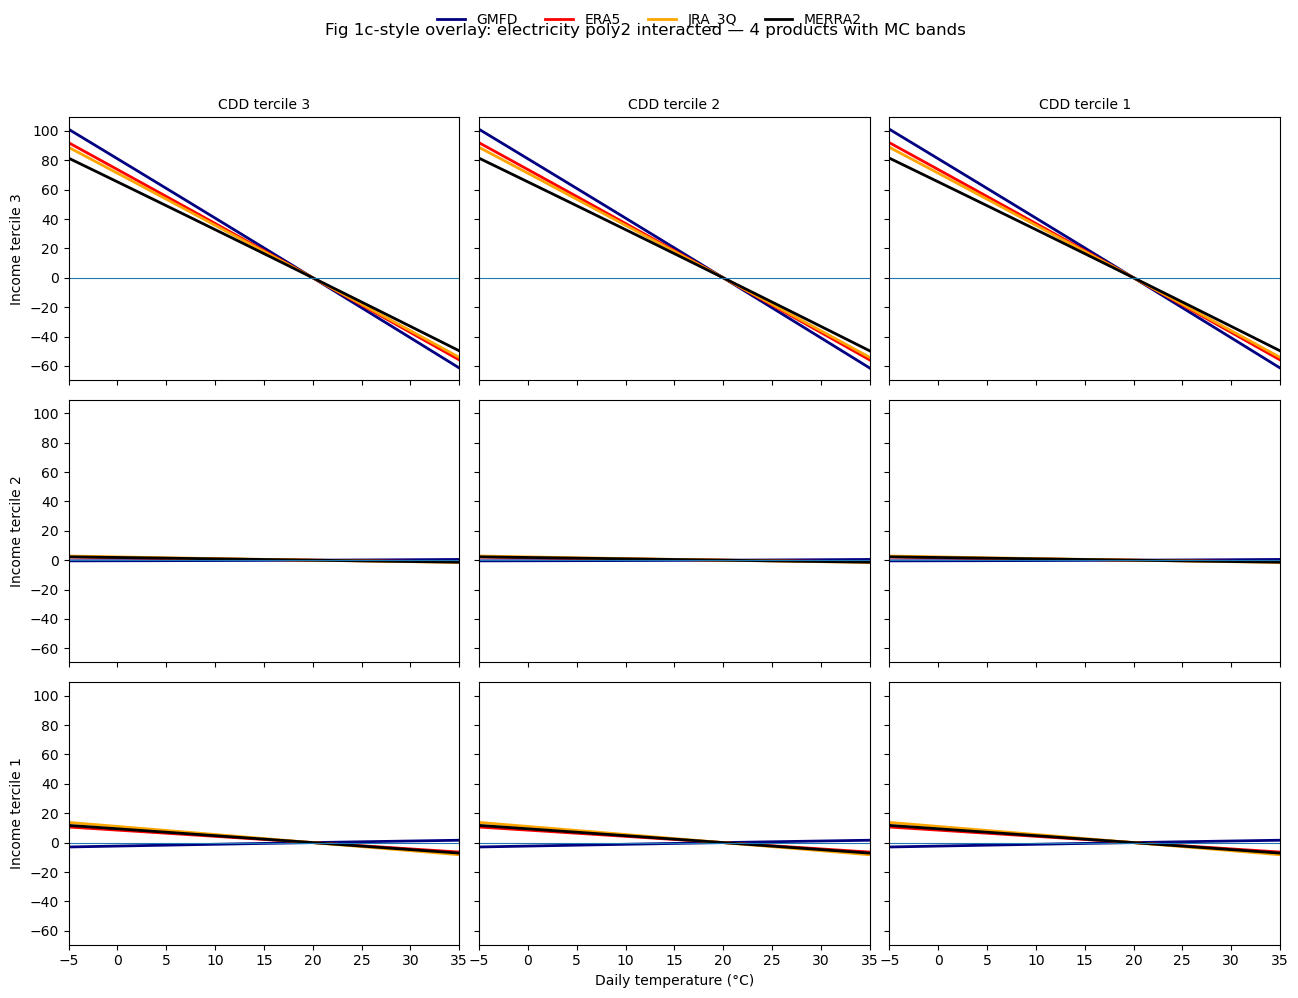

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# ============================================================
# CONFIG
# ============================================================
PROJECT = Path("/user/ab5405/summeraliaclimate/code/energy_uncertainty")
REGD    = PROJECT / "data" / "regression"
STERD   = REGD / "sters"
OUTDIR  = PROJECT / "output" / "figures"
OUTDIR.mkdir(parents=True, exist_ok=True)

FUEL = "electricity"          # "electricity" or "other_energy"
PG   = 1 if FUEL == "electricity" else 2

BREAK_DATA = "/user/ab5405/summeraliaclimate/code/energy_consumption/energy_data_release_2021oct21/DATA/regression/break_data_TINV_clim.dta"
PRODUCTS = ["GMFD", "ERA5", "JRA_3Q", "MERRA2"]
COLOR = {"GMFD": "navy", "ERA5": "red", "JRA_3Q": "orange", "MERRA2": "black"}

# Choose which ster outputs you are actually exporting
# If you truly have quadinter files, keep "quadinter".
# If you intended Fig 1c spec, this is usually "inter".
MODEL_TAG = "TINV_clim"
SPEC_TAG  = "quadinter"  # change to "inter" if that’s what you meant

COEF_PATH = {p: STERD / f"FD_FGLS_inter_{MODEL_TAG}_{SPEC_TAG}_{p}_coeff.csv" for p in PRODUCTS}
VCOV_PATH = {p: STERD / f"FD_FGLS_inter_{MODEL_TAG}_{SPEC_TAG}_{p}_vcov_long.csv" for p in PRODUCTS}

# Temperature grid
TMIN, TMAX = -5, 35
T = np.arange(TMIN, TMAX + 1, 1).astype(float)

# MC settings
N_DRAWS = 2000
SEED = 123
BAND_PCTS = (2.5, 97.5)

ALPHA_BAND = 0.15
LW = 2.0

# If your y-axis is ~365x too big, flip this to True
# (depends on how your dependent var / aggregation is scaled)
DIVIDE_BY_365 = False


# ============================================================
# IO helpers
# ============================================================
def read_coeff_series(path: Path) -> pd.Series:
    df = pd.read_csv(path)
    return pd.Series(df["beta"].values, index=df["parm"].astype(str).values)

def read_vcov_long(path: Path) -> pd.DataFrame:
    df = pd.read_csv(path)
    df["parm_i"] = df["parm_i"].astype(str)
    df["parm_j"] = df["parm_j"].astype(str)
    return df

def vcov_submatrix(vlong: pd.DataFrame, names: list[str]) -> np.ndarray:
    sub = vlong[vlong["parm_i"].isin(names) & vlong["parm_j"].isin(names)]
    need = len(names) * len(names)
    if sub.shape[0] != need:
        have_pairs = set(zip(sub["parm_i"], sub["parm_j"]))
        missing = [(i, j) for i in names for j in names if (i, j) not in have_pairs]
        raise ValueError(f"VCV missing entries (showing first 10): {missing[:10]}")
    V = (sub.pivot(index="parm_i", columns="parm_j", values="v")
            .reindex(index=names, columns=names)
            .values.astype(float))
    return V


# ============================================================
# Fig 1c poly2 interacted design matrix
# ============================================================
def param_list(pg: int, ig: int) -> list[str]:
    """
    Exactly the parameters used in the Fig 1c poly2 interacted response.
    (No year / year2 terms.)
    """
    out = []
    for k in (1, 2):
        out.append(f"c.indp{pg}#c.indf1#c.FD_temp{k}")
        out.append(f"c.indp{pg}#c.indf1#c.FD_cdd20_TINVtemp{k}")
        out.append(f"c.indp{pg}#c.indf1#c.FD_hdd20_TINVtemp{k}")
        out.append(f"c.indp{pg}#c.indf1#c.FD_dc1_lgdppc_MA15I{ig}temp{k}")
    return out

def build_X(T: np.ndarray, *, subCDD: float, subHDD: float, deltacut: float) -> np.ndarray:
    """
    Returns X with columns aligned to param_list(pg, ig):
      for k=1,2 blocks:
        tempk:     (T^k - 20^k)
        cddk:      1[T>=20] * subCDD * (T^k - 20^k)
        hddk:      1[T<20]  * subHDD * (20^k - T^k)
        dc1k:      deltacut * (T^k - 20^k)
    """
    T = np.asarray(T, float)
    above20 = (T >= 20.0).astype(float)
    below20 = (T <  20.0).astype(float)

    cols = []
    for k in (1, 2):
        Tk = T**k
        base = (Tk - 20.0**k)

        cols.append(base)                                   # FD_temp{k}
        cols.append(above20 * subCDD * base)                # FD_cdd20_TINVtemp{k}
        cols.append(below20 * subHDD * (20.0**k - Tk))       # FD_hdd20_TINVtemp{k}
        cols.append(deltacut * base)                         # FD_dc1...temp{k}

    X = np.column_stack(cols)
    return X


# ============================================================
# One product, one cell: point + MC band
# ============================================================
def product_cell_curve(product: str, *, pg: int, subCDD: float, subHDD: float, subInc: float, ibar: float):
    coef = read_coeff_series(COEF_PATH[product])
    vlong = read_vcov_long(VCOV_PATH[product])

    ig = 2 if subInc > ibar else 1
    deltacut = float(subInc - ibar)

    names = param_list(pg, ig)

    # sanity: all required params present
    missing = [n for n in names if n not in coef.index]
    if missing:
        raise KeyError(
            f"{product}: missing {len(missing)} required coefficients.\n"
            f"First few: {missing[:8]}\n"
            f"Tip: check whether your exported parm names include '_GMFD' suffix or other differences."
        )

    b = np.array([coef[n] for n in names], float)
    V = vcov_submatrix(vlong, names)

    X = build_X(T, subCDD=subCDD, subHDD=subHDD, deltacut=deltacut)

    # point estimate
    y = X @ b

    # MC
    rng = np.random.default_rng(SEED)
    draws = rng.multivariate_normal(mean=b, cov=V, size=N_DRAWS)   # (N, P)
    Y = draws @ X.T                                                # (N, len(T))
    lo, hi = np.percentile(Y, BAND_PCTS, axis=0)

    if DIVIDE_BY_365:
        y  = y / 365.0
        lo = lo / 365.0
        hi = hi / 365.0

    return y, lo, hi


# ============================================================
# Break data → 3×3 cell covariates (match their Stata indexing)
# ============================================================
bd = pd.read_stata(BREAK_DATA)

# ibar (income knot)
max_col = f"maxInc_largegpid_{FUEL}"
lgpid_col = f"largegpid_{FUEL}"
ibar = float(bd.loc[bd[lgpid_col] == 1, max_col].max())

# reproduce: duplicates drop tpid tgpid; sort tpid tgpid
bd2 = bd.drop_duplicates(subset=["tpid", "tgpid"]).copy()
bd2 = bd2.sort_values(["tpid", "tgpid"]).reset_index(drop=True)

def cell_covariates(lg: int, tr: int):
    """
    Stata:
      tr_index = tr*3
      subCDD = avgCDD_tpid[tr_index]
    where Stata indexing is 1-based.
    So python idx = tr*3 - 1.
    """
    idx = tr * 3 - 1
    subCDD = float(bd2.loc[idx, "avgCDD_tpid"])
    subHDD = float(bd2.loc[idx, "avgHDD_tpid"])
    subInc = float(bd2.loc[lg - 1, "avgInc_tgpid"])  # lg=1..3 → 0..2
    return subCDD, subHDD, subInc


# ============================================================
# PLOT
# ============================================================
fig, axes = plt.subplots(3, 3, figsize=(13, 10), sharex=True, sharey=True)

for r, lg in enumerate([3, 2, 1]):      # top→bottom
    for c, tr in enumerate([3, 2, 1]):  # left→right (you can flip if you want)
        ax = axes[r, c]
        subCDD, subHDD, subInc = cell_covariates(lg, tr)

        for p in PRODUCTS:
            y, lo, hi = product_cell_curve(
                p, pg=PG, subCDD=subCDD, subHDD=subHDD, subInc=subInc, ibar=ibar
            )
            ax.fill_between(T, lo, hi, alpha=ALPHA_BAND, linewidth=0, color=COLOR[p])
            ax.plot(T, y, lw=LW, color=COLOR[p], label=p)

        ax.axhline(0, lw=0.8)
        ax.set_xlim(TMIN, TMAX)

        if r == 0:
            ax.set_title(f"CDD tercile {tr}", fontsize=10)
        if c == 0:
            ax.set_ylabel(f"Income tercile {lg}", fontsize=10)

axes[-1, 1].set_xlabel("Daily temperature (°C)")

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=4, frameon=False)

scale_note = " (÷365)" if DIVIDE_BY_365 else ""
fig.suptitle(
    f"Fig 1c-style overlay: {FUEL} poly2 interacted — 4 products with MC bands{scale_note}",
    y=0.98
)

plt.tight_layout(rect=[0, 0, 1, 0.95])

outpath = OUTDIR / f"fig1c_overlay4_{FUEL}_poly2_mc_{SPEC_TAG}.png"
plt.savefig(outpath, dpi=200)
print("Saved:", outpath)
plt.show()


In [10]:
bd = pd.read_stata(BREAK_DATA)
print("Columns containing 'Inc':")
print([c for c in bd.columns if "Inc" in c or "inc" in c or "gdp" in c.lower()][:80])

# show ranges for likely candidates
cand = [c for c in bd.columns if any(s in c.lower() for s in ["inc", "gdp", "lgdppc", "loggdp"])]
for c in cand[:25]:
    try:
        s = bd[c].dropna()
        print(c, "min", float(s.min()), "max", float(s.max()))
    except Exception:
        pass


Columns containing 'Inc':
['lgdppc_MA15', 'avgInc_tgpid', 'avgInc_tpid', 'maxInc_gpid', 'maxInc_largegpid_other_energy', 'maxInc_largegpid_electricity']
lgdppc_MA15 min 5.7416902887129995 max 12.413788585126872
avgInc_tgpid min 7.4978461265563965 max 9.997271537780762
avgInc_tpid min 8.426518440246582 max 9.39260196685791
maxInc_gpid min 7.245798587799072 max 12.413788795471191
maxInc_largegpid_other_energy min 7.712954044342041 max 12.413788795471191
maxInc_largegpid_electricity min 9.087010383605957 max 12.413788795471191


Using ibar = 9.087010383605957 from maxInc_largegpid_electricity
Using income col = avgInc_tgpid range (np.float32(7.497846), np.float32(9.997272))
Saved: /user/ab5405/summeraliaclimate/code/energy_uncertainty/output/figures/fig1c_overlay4_electricity_poly2_interacted_mc.png


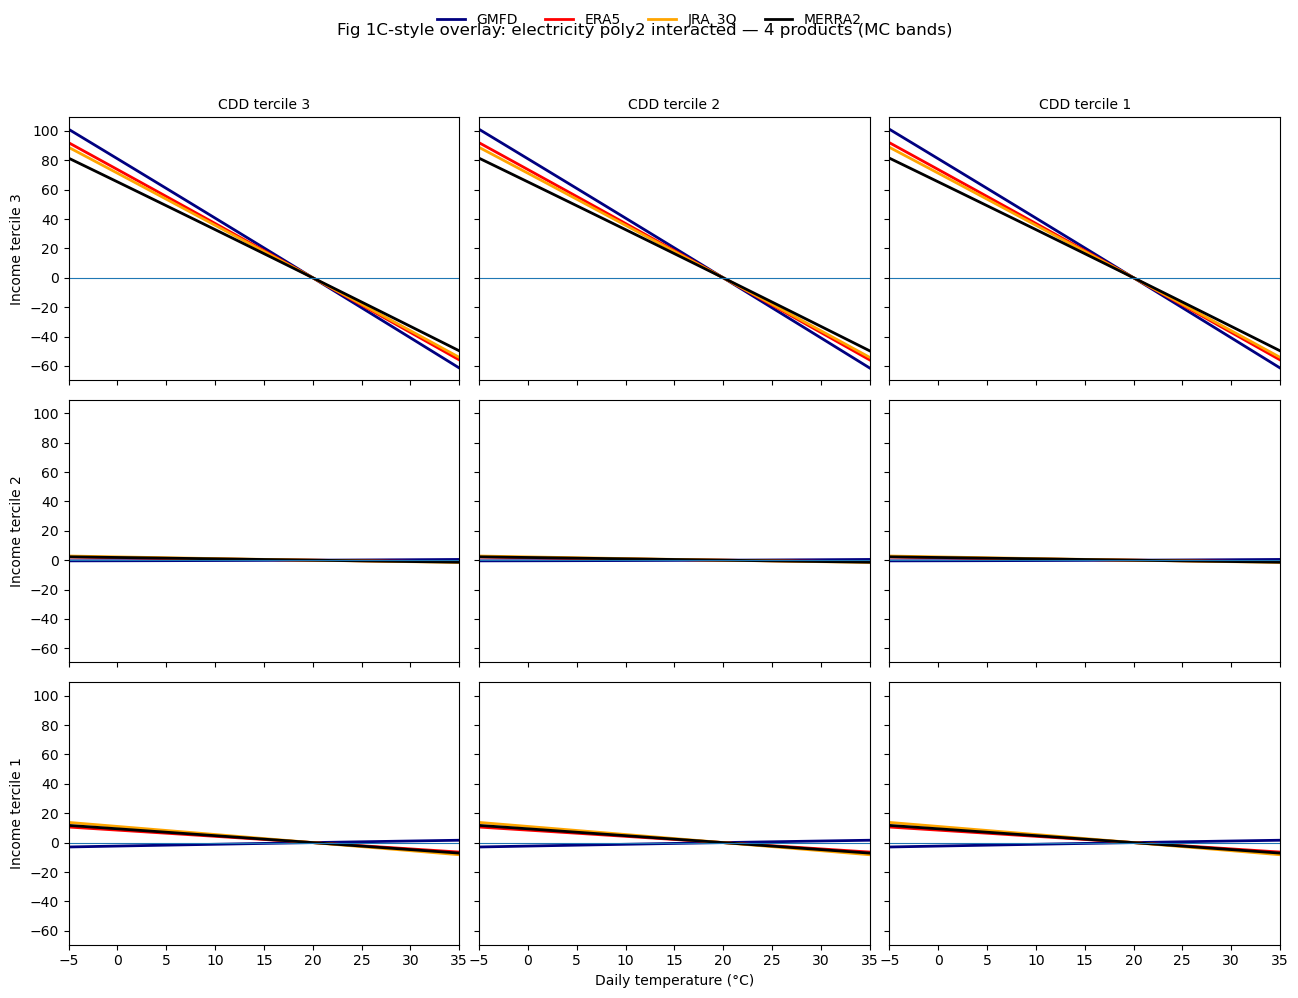

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# =========================
# CONFIG
# =========================
PROJECT = Path("/user/ab5405/summeraliaclimate/code/energy_uncertainty")
REGD    = PROJECT / "data" / "regression"
STERD   = REGD / "sters"
OUTDIR  = PROJECT / "output" / "figures"
OUTDIR.mkdir(parents=True, exist_ok=True)

FUEL = "electricity"              # "electricity" or "other_energy"
PG   = 1 if FUEL == "electricity" else 2

BREAK_DATA = "/user/ab5405/summeraliaclimate/code/energy_consumption/energy_data_release_2021oct21/DATA/regression/break_data_TINV_clim.dta"
PRODUCTS = ["GMFD", "ERA5", "JRA_3Q", "MERRA2"]

# pick the RIGHT model stem you actually exported
# e.g. FD_FGLS_inter_TINV_clim_ERA5_coeff.csv (no quadinter) OR
#      FD_FGLS_inter_TINV_clim_quadinter_ERA5_coeff.csv
MODEL_STEM = "FD_FGLS_inter_TINV_clim_quadinter"           # <-- CHANGE if needed

COEF_PATH = {p: STERD / f"{MODEL_STEM}_{p}_coeff.csv" for p in PRODUCTS}
VCOV_PATH = {p: STERD / f"{MODEL_STEM}_{p}_vcov_long.csv" for p in PRODUCTS}

# temperature grid (paper uses -5..35)
T = np.arange(-5, 36, 1).astype(float)

# Monte Carlo
N_DRAWS = 2000
SEED = 123
LO_PCT, HI_PCT = 2.5, 97.5

COLOR = {"GMFD":"navy", "ERA5":"red", "JRA_3Q":"orange", "MERRA2":"black"}
BAND_ALPHA = 0.15
LW = 2.0

# =========================
# IO HELPERS
# =========================
def read_coeff_series(path: Path) -> pd.Series:
    df = pd.read_csv(path)
    return pd.Series(df["beta"].values, index=df["parm"].astype(str).values)

def read_vcov_long(path: Path) -> pd.DataFrame:
    df = pd.read_csv(path)
    df["parm_i"] = df["parm_i"].astype(str)
    df["parm_j"] = df["parm_j"].astype(str)
    return df

def vcov_submatrix(vlong: pd.DataFrame, names: list[str]) -> np.ndarray:
    sub = vlong[vlong["parm_i"].isin(names) & vlong["parm_j"].isin(names)]
    need = len(names) * len(names)
    if sub.shape[0] != need:
        missing = set((i, j) for i in names for j in names) - set(zip(sub["parm_i"], sub["parm_j"]))
        raise ValueError(f"VCOV missing entries (showing a few): {list(missing)[:8]}")
    V = (sub.pivot(index="parm_i", columns="parm_j", values="v")
            .reindex(index=names, columns=names)
            .values.astype(float))
    return V

# =========================
# NAME RESOLUTION (NO SILENT ZEROS)
# =========================
def pick_param_name(coef: pd.Series, base: str, product: str) -> str:
    """
    Try common variants. If none exist, raise immediately.
    """
    cands = [
        base,
        base + "_GMFD",              # common in original paper scripts
        base + f"_{product}",        # some exports suffix by product
        base + f"_{product}_GMFD",   # rare but safe to try
    ]
    for c in cands:
        if c in coef.index:
            return c
    raise KeyError(f"Could not find coefficient for base='{base}' in {product}. Tried: {cands}")

def resolve_needed_names(coef: pd.Series, product: str, pg: int, ig: int) -> dict:
    out = {}
    for k in (1, 2):
        out[f"temp{k}"] = pick_param_name(coef, f"c.indp{pg}#c.indf1#c.FD_temp{k}", product)
        out[f"cdd{k}"]  = pick_param_name(coef, f"c.indp{pg}#c.indf1#c.FD_cdd20_TINVtemp{k}", product)
        out[f"hdd{k}"]  = pick_param_name(coef, f"c.indp{pg}#c.indf1#c.FD_hdd20_TINVtemp{k}", product)
        out[f"dc1{k}"]  = pick_param_name(coef, f"c.indp{pg}#c.indf1#c.FD_dc1_lgdppc_MA15I{ig}temp{k}", product)
    return out

# =========================
# RESPONSE FUNCTION (poly2, kink at 20)
# =========================
def dose_response_poly2(T, b, subCDD, subHDD, deltacut):
    """
    b contains:
      temp1,temp2,cdd1,cdd2,hdd1,hdd2,dc11,dc12  (in this order)
    """
    T = np.asarray(T, dtype=float)
    above = (T >= 20.0).astype(float)
    below = (T <  20.0).astype(float)

    y = np.zeros_like(T, dtype=float)

    # unpack
    b_temp1, b_temp2, b_cdd1, b_cdd2, b_hdd1, b_hdd2, b_dc11, b_dc12 = b

    for k, b_temp, b_cdd, b_hdd, b_dc1 in [
        (1, b_temp1, b_cdd1, b_hdd1, b_dc11),
        (2, b_temp2, b_cdd2, b_hdd2, b_dc12),
    ]:
        Tk = T**k
        base = (Tk - 20.0**k)

        y += b_temp * base
        y += above * (b_cdd * subCDD * base)
        y += below * (b_hdd * subHDD * (20.0**k - Tk))
        y += b_dc1 * deltacut * base

    # This is already "relative to 20C" because every term uses (T^k - 20^k)
    return y

# =========================
# BREAK DATA → CELL COVARIATES
# =========================
bd = pd.read_stata(BREAK_DATA)
bd2 = (bd.drop_duplicates(subset=["tpid","tgpid"])
         .sort_values(["tpid","tgpid"])
         .reset_index(drop=True))

# knot (ibar) must match the paper logic
max_col  = f"maxInc_largegpid_{FUEL}"
flag_col = f"largegpid_{FUEL}"
ibar = float(bd.loc[bd[flag_col] == 1, max_col].max())

# income used for tercile means
INC_COL = "avgInc_tgpid"   # your output shows this is in ~7.5..10 range (log-scale)

def get_cell_covariates(lg: int, tr: int):
    # replicate Stata: tr_index = tr*3 (1-based) -> positions 2,5,8 in 0-based
    idx = tr * 3 - 1
    subCDD = float(bd2.loc[idx, "avgCDD_tpid"])
    subHDD = float(bd2.loc[idx, "avgHDD_tpid"])
    subInc = float(bd2.loc[lg - 1, INC_COL])  # lg=1..3 => 0..2
    return subCDD, subHDD, subInc

print("Using ibar =", ibar, "from", max_col)
print("Using income col =", INC_COL, "range", (bd2[INC_COL].min(), bd2[INC_COL].max()))

# =========================
# ONE PRODUCT IN ONE CELL: POINT + MC BAND
# =========================
def mc_band_product_cell(product: str, subCDD: float, subHDD: float, subInc: float):
    coef  = read_coeff_series(COEF_PATH[product])
    vlong = read_vcov_long(VCOV_PATH[product])

    deltacut = float(subInc - ibar)
    ig = 2 if subInc > ibar else 1

    name_map = resolve_needed_names(coef, product, PG, ig)
    names = [
        name_map["temp1"], name_map["temp2"],
        name_map["cdd1"],  name_map["cdd2"],
        name_map["hdd1"],  name_map["hdd2"],
        name_map["dc11"],  name_map["dc12"],
    ]

    # print once to verify we’re not missing temp2 etc.
    # (comment out after you confirm)
    # print(product, "resolved names:", names)

    b = np.array([float(coef[n]) for n in names], dtype=float)
    V = vcov_submatrix(vlong, names)

    y_hat = dose_response_poly2(T, b, subCDD, subHDD, deltacut)

    rng = np.random.default_rng(SEED)
    draws = rng.multivariate_normal(mean=b, cov=V, size=N_DRAWS)

    Y = np.vstack([dose_response_poly2(T, draws[i], subCDD, subHDD, deltacut) for i in range(N_DRAWS)])
    lo = np.percentile(Y, LO_PCT, axis=0)
    hi = np.percentile(Y, HI_PCT, axis=0)

    return y_hat, lo, hi

# =========================
# PLOT 3×3 WITH 4-PRODUCT OVERLAY
# =========================
fig, axes = plt.subplots(3, 3, figsize=(13, 10), sharex=True, sharey=True)

for r, lg in enumerate([3, 2, 1]):
    for c, tr in enumerate([3, 2, 1]):
        ax = axes[r, c]
        subCDD, subHDD, subInc = get_cell_covariates(lg, tr)

        # sanity print for one cell if you want
        # if (lg, tr) == (3, 3):
        #     print("Example cell:", "subInc", subInc, "ibar", ibar, "deltacut", subInc-ibar, "CDD", subCDD, "HDD", subHDD)

        for p in PRODUCTS:
            y, lo, hi = mc_band_product_cell(p, subCDD, subHDD, subInc)
            ax.fill_between(T, lo, hi, alpha=BAND_ALPHA, linewidth=0, color=COLOR[p])
            ax.plot(T, y, lw=LW, color=COLOR[p], label=p)

        ax.axhline(0, lw=0.8)
        ax.set_xlim(T.min(), T.max())

        if r == 0:
            ax.set_title(f"CDD tercile {tr}", fontsize=10)
        if c == 0:
            ax.set_ylabel(f"Income tercile {lg}", fontsize=10)

axes[-1, 1].set_xlabel("Daily temperature (°C)")

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=4, frameon=False)

fig.suptitle(f"Fig 1C-style overlay: {FUEL} poly2 interacted — 4 products (MC bands)", y=0.98)
plt.tight_layout(rect=[0, 0, 1, 0.95])

outpath = OUTDIR / f"fig1c_overlay4_{FUEL}_poly2_interacted_mc.png"
plt.savefig(outpath, dpi=200)
print("Saved:", outpath)
plt.show()


In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def component_contribs_poly2(T, b, subCDD, subHDD, deltacut):
    """
    Return dict of components (each len(T)) so we can see dominance.
    b ordering:
      temp1,temp2,cdd1,cdd2,hdd1,hdd2,dc11,dc12
    """
    T = np.asarray(T, dtype=float)
    above = (T >= 20.0).astype(float)
    below = (T <  20.0).astype(float)

    b_temp1, b_temp2, b_cdd1, b_cdd2, b_hdd1, b_hdd2, b_dc11, b_dc12 = b

    comps = {
        "temp_base": np.zeros_like(T),
        "CDD_inter": np.zeros_like(T),
        "HDD_inter": np.zeros_like(T),
        "INC_inter": np.zeros_like(T),
    }

    for k, b_temp, b_cdd, b_hdd, b_dc1 in [
        (1, b_temp1, b_cdd1, b_hdd1, b_dc11),
        (2, b_temp2, b_cdd2, b_hdd2, b_dc12),
    ]:
        Tk = T**k
        base = (Tk - 20.0**k)

        comps["temp_base"] += b_temp * base
        comps["CDD_inter"] += above * (b_cdd * subCDD * base)
        comps["HDD_inter"] += below * (b_hdd * subHDD * (20.0**k - Tk))
        comps["INC_inter"] += b_dc1 * deltacut * base

    comps["total"] = comps["temp_base"] + comps["CDD_inter"] + comps["HDD_inter"] + comps["INC_inter"]
    return comps


def debug_one_cell_one_product(
    product, lg, tr,
    *, T, PG, bd2, INC_COL, ibar,
    COEF_PATH, VCOV_PATH,
    read_coeff_series, read_vcov_long, vcov_submatrix,
    resolve_needed_names,
    N_DRAWS=500, SEED=123,
    daily=True,
):
    # --- get cell covariates (your Stata indexing logic) ---
    idx = tr * 3 - 1  # 1-based -> 0-based
    subCDD = float(bd2.loc[idx, "avgCDD_tpid"])
    subHDD = float(bd2.loc[idx, "avgHDD_tpid"])
    subInc = float(bd2.loc[lg - 1, INC_COL])

    deltacut = subInc - ibar
    ig = 2 if subInc > ibar else 1

    # --- load coef/vcov ---
    coef  = read_coeff_series(COEF_PATH[product])
    vlong = read_vcov_long(VCOV_PATH[product])

    # --- resolve needed names ---
    name_map = resolve_needed_names(coef, product, PG, ig)
    names = [
        name_map["temp1"], name_map["temp2"],
        name_map["cdd1"],  name_map["cdd2"],
        name_map["hdd1"],  name_map["hdd2"],
        name_map["dc11"],  name_map["dc12"],
    ]

    b = np.array([float(coef[n]) for n in names], dtype=float)
    V = vcov_submatrix(vlong, names)

    # --- point components ---
    comps = component_contribs_poly2(T, b, subCDD, subHDD, deltacut)
    scale = 365.0 if daily else 1.0
    comps_scaled = {k: v/scale for k,v in comps.items()}

    # --- MC band on total only (faster) ---
    rng = np.random.default_rng(SEED)
    draws = rng.multivariate_normal(mean=b, cov=V, size=N_DRAWS)
    Y = np.vstack([
        component_contribs_poly2(T, draws[i], subCDD, subHDD, deltacut)["total"]/scale
        for i in range(N_DRAWS)
    ])
    lo, hi = np.percentile(Y, [2.5, 97.5], axis=0)

    # --- print diagnostics ---
    def r(x): return (float(np.min(x)), float(np.max(x)))

    print("="*80)
    print(f"DEBUG product={product} fuelPG={PG} cell(lg={lg}, tr={tr}) daily={daily}")
    print(f"subInc={subInc:.4f}  ibar={ibar:.4f}  deltacut={deltacut:.4f}  ig={ig}")
    print(f"subCDD={subCDD:.4f}  subHDD={subHDD:.4f}")
    print("Resolved names:")
    for k in names:
        print("   ", k)
    print("Coeff values (in same order):")
    print(b)

    print("Component ranges (after scaling):")
    for k in ["temp_base","CDD_inter","HDD_inter","INC_inter","total"]:
        print(f"  {k:10s}  min/max = {r(comps_scaled[k])}")

    print(f"TOTAL with MC band: total min/max = {r(comps_scaled['total'])}, lo/hi at endpoints = {(lo[0], hi[0])} .. {(lo[-1], hi[-1])}")

    # --- plot decomposition + band ---
    fig, ax = plt.subplots(figsize=(8,5))
    ax.fill_between(T, lo, hi, alpha=0.2, linewidth=0, label="MC 95% band (total)")
    ax.plot(T, comps_scaled["total"], lw=2, label="total (point)")
    ax.plot(T, comps_scaled["temp_base"], lw=1, linestyle="--", label="temp_base")
    ax.plot(T, comps_scaled["CDD_inter"], lw=1, linestyle="--", label="CDD_inter")
    ax.plot(T, comps_scaled["HDD_inter"], lw=1, linestyle="--", label="HDD_inter")
    ax.plot(T, comps_scaled["INC_inter"], lw=1, linestyle="--", label="INC_inter")
    ax.axhline(0, lw=0.8)
    ax.set_xlabel("Daily temperature (°C)")
    ax.set_ylabel("Δ consumption (GJ/cap/day) rel 20°C" if daily else "Δ consumption (GJ/cap/year) rel 20°C")
    ax.set_title(f"{product} — cell lg={lg}, tr={tr}")
    ax.legend(frameon=False, ncol=2)
    plt.tight_layout()
    plt.show()

    return comps_scaled, (lo, hi)


DEBUG product=GMFD fuelPG=1 cell(lg=3, tr=3) daily=True
subInc=9.9973  ibar=9.0870  deltacut=0.9103  ig=2
subCDD=223.8360  subHDD=3925.8040
Resolved names:
    c.indp1#c.indf1#c.FD_temp1
    c.indp1#c.indf1#c.FD_temp2
    c.indp1#c.indf1#c.FD_cdd20_TINVtemp1
    c.indp1#c.indf1#c.FD_cdd20_TINVtemp2
    c.indp1#c.indf1#c.FD_hdd20_TINVtemp1
    c.indp1#c.indf1#c.FD_hdd20_TINVtemp2
    c.indp1#c.indf1#c.FD_dc1_lgdppc_MA15I2temp1
    c.indp1#c.indf1#c.FD_dc1_lgdppc_MA15I2temp2
Coeff values (in same order):
[-1.40050278e-02  5.11251901e-04  1.36451058e-07 -5.72468673e-10
  3.83969098e-08  2.40220521e-09 -4.40728157e+00 -1.93637342e-03]
Component ranges (after scaling):
  temp_base   min/max = (-5.5521154070909574e-05, 0.0005800202796058232)
  CDD_inter   min/max = (0.0, 9.655482255186857e-07)
  HDD_inter   min/max = (0.0, 2.0013530196677323e-05)
  INC_inter   min/max = (-0.1688515278201606, 0.2765901568596509)
  total       min/max = (-0.16827054199232924, 0.27704416006488086)
TOTAL with MC

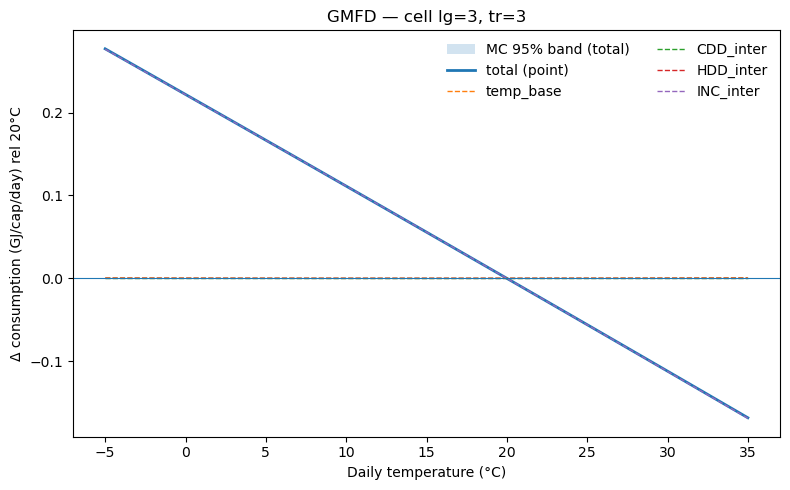

({'temp_base': array([ 4.33989675e-04,  3.83013525e-04,  3.34838755e-04,  2.89465365e-04,
          2.46893355e-04,  2.07122726e-04,  1.70153477e-04,  1.35985608e-04,
          1.04619120e-04,  7.60540117e-05,  5.02902839e-05,  2.73279363e-05,
          7.16696901e-06, -1.01926180e-05, -2.47508247e-05, -3.65076511e-05,
         -4.54630973e-05, -5.16171632e-05, -5.49698488e-05, -5.55211541e-05,
         -5.32710791e-05, -4.82196238e-05, -4.03667883e-05, -2.97125725e-05,
         -1.62569764e-05,  0.00000000e+00,  1.90583567e-05,  4.09180936e-05,
          6.55792108e-05,  9.30417084e-05,  1.23305586e-04,  1.56370844e-04,
          1.92237483e-04,  2.30905501e-04,  2.72374900e-04,  3.16645679e-04,
          3.63717839e-04,  4.13591379e-04,  4.66266299e-04,  5.21742599e-04,
          5.80020280e-04]),
  'CDD_inter': array([0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
         0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
         0.00000000e+00, 0.000

In [16]:
# Make sure these match your current objects:
# T, bd2, INC_COL, ibar, COEF_PATH, VCOV_PATH, PRODUCTS, etc.

debug_one_cell_one_product(
    "GMFD", lg=3, tr=3,
    T=T, PG=PG, bd2=bd2, INC_COL=INC_COL, ibar=ibar,
    COEF_PATH=COEF_PATH, VCOV_PATH=VCOV_PATH,
    read_coeff_series=read_coeff_series,
    read_vcov_long=read_vcov_long,
    vcov_submatrix=vcov_submatrix,
    resolve_needed_names=resolve_needed_names,
    N_DRAWS=500,   # keep it quick
    daily=True,    # IMPORTANT: paper’s axis is daily, so start with True
)


In [17]:
terms = pd.Index(coef.index)

print("Any polyBelow?", terms.str.contains("polyBelow").any())
print("Any polyAbove?", terms.str.contains("polyAbove").any())
print("Any TINVtemp?", terms.str.contains("TINVtemp").any())
print("Any temp[34]?", terms.str.contains(r"FD_temp[34]\b").any())

print("Top matches:", terms[terms.str.contains("polyBelow|polyAbove|FD_temp|TINVtemp", regex=True)][:50])


Any polyBelow? False
Any polyAbove? False
Any TINVtemp? True
Any temp[34]? False
Top matches: Index(['c.indp1#c.indf1#c.FD_temp1', 'c.indp1#c.indf1#c.FD_temp2',
       'c.indp2#c.indf1#c.FD_temp1', 'c.indp2#c.indf1#c.FD_temp2',
       'c.indp1#c.indf1#c.FD_hdd20_TINVtemp1',
       'c.indp1#c.indf1#c.FD_cdd20_TINVtemp1',
       'c.indp1#c.indf1#c.FD_hdd20_TINVtemp2',
       'c.indp1#c.indf1#c.FD_cdd20_TINVtemp2',
       'c.indp2#c.indf1#c.FD_hdd20_TINVtemp1',
       'c.indp2#c.indf1#c.FD_cdd20_TINVtemp1',
       'c.indp2#c.indf1#c.FD_hdd20_TINVtemp2',
       'c.indp2#c.indf1#c.FD_cdd20_TINVtemp2'],
      dtype='object')


In [18]:
b_test = b.copy()
b_test[6] = 0.0
b_test[7] = 0.0
comps_noinc = component_contribs_poly2(T, b_test, subCDD, subHDD, deltacut)["total"]/365
print(comps_noinc.min(), comps_noinc.max())

NameError: name 'b' is not defined

In [19]:
def compute_response_auto(
    coef: pd.Series,
    T: np.ndarray,
    *,
    pg: int,
    subCDD: float,
    subHDD: float,
    subInc: float,
    ibar: float,
    daily: bool = True,
):
    """
    Auto-detect basis:
      - If polyBelow/polyAbove exist, use spline around 20C (recommended for Fig1c shape).
      - Else use temp1/temp2 + HDD/CDD interactions (your current approach).
    """
    T = np.asarray(T, dtype=float)
    above = (T >= 20.0).astype(float)
    below = (T <  20.0).astype(float)

    deltacut = subInc - ibar
    ig = 2 if subInc > ibar else 1
    scale = 365.0 if daily else 1.0

    # ---------- Case 1: spline basis ----------
    has_poly = any(("polyBelow" in s) or ("polyAbove" in s) for s in coef.index)

    if has_poly:
        # Define spline basis around 20
        hot1  = above * (T - 20.0)
        hot2  = above * (T - 20.0)**2
        cold1 = below * (20.0 - T)
        cold2 = below * (20.0 - T)**2

        # You MUST map these to your actual coefficient names in YOUR export.
        # Common patterns (you may need to print matching names once and adjust):
        #   FD_polyAbove1, FD_polyAbove2, FD_polyBelow1, FD_polyBelow2
        # plus interactions with income and long-run climate.
        def get(name, default=0.0):
            return float(coef[name]) if name in coef.index else float(default)

        y = np.zeros_like(T)

        # base spline terms
        y += get(f"c.indp{pg}#c.indf1#c.FD_polyBelow1") * (-cold1)
        y += get(f"c.indp{pg}#c.indf1#c.FD_polyBelow2") * (-cold2)
        y += get(f"c.indp{pg}#c.indf1#c.FD_polyAbove1") * ( hot1)
        y += get(f"c.indp{pg}#c.indf1#c.FD_polyAbove2") * ( hot2)

        # income interactions (if present)
        y += get(f"c.indp{pg}#c.indf1#c.FD_dc1_lgdppc_MA15I{ig}polyBelow1") * deltacut * (-cold1)
        y += get(f"c.indp{pg}#c.indf1#c.FD_dc1_lgdppc_MA15I{ig}polyBelow2") * deltacut * (-cold2)
        y += get(f"c.indp{pg}#c.indf1#c.FD_dc1_lgdppc_MA15I{ig}polyAbove1") * deltacut * ( hot1)
        y += get(f"c.indp{pg}#c.indf1#c.FD_dc1_lgdppc_MA15I{ig}polyAbove2") * deltacut * ( hot2)

        # long-run climate interactions (if present)
        y += get(f"c.indp{pg}#c.indf1#c.FD_cdd20_polyAbove1") * subCDD * ( hot1)
        y += get(f"c.indp{pg}#c.indf1#c.FD_cdd20_polyAbove2") * subCDD * ( hot2)
        y += get(f"c.indp{pg}#c.indf1#c.FD_hdd20_polyBelow1") * subHDD * (-cold1)
        y += get(f"c.indp{pg}#c.indf1#c.FD_hdd20_polyBelow2") * subHDD * (-cold2)

        return y / scale

    # ---------- Case 2: fallback to your current polynomial ----------
    # (this is what produced the near-line in your debug)
    b_temp1 = float(coef.get(f"c.indp{pg}#c.indf1#c.FD_temp1", 0.0))
    b_temp2 = float(coef.get(f"c.indp{pg}#c.indf1#c.FD_temp2", 0.0))
    b_cdd1  = float(coef.get(f"c.indp{pg}#c.indf1#c.FD_cdd20_TINVtemp1", 0.0))
    b_cdd2  = float(coef.get(f"c.indp{pg}#c.indf1#c.FD_cdd20_TINVtemp2", 0.0))
    b_hdd1  = float(coef.get(f"c.indp{pg}#c.indf1#c.FD_hdd20_TINVtemp1", 0.0))
    b_hdd2  = float(coef.get(f"c.indp{pg}#c.indf1#c.FD_hdd20_TINVtemp2", 0.0))
    b_dc11  = float(coef.get(f"c.indp{pg}#c.indf1#c.FD_dc1_lgdppc_MA15I{ig}temp1", 0.0))
    b_dc12  = float(coef.get(f"c.indp{pg}#c.indf1#c.FD_dc1_lgdppc_MA15I{ig}temp2", 0.0))

    Tk1 = T
    Tk2 = T**2
    base1 = (Tk1 - 20.0)
    base2 = (Tk2 - 20.0**2)

    y = (b_temp1 * base1 + b_temp2 * base2
         + above * (b_cdd1 * subCDD * base1 + b_cdd2 * subCDD * base2)
         + below * (b_hdd1 * subHDD * (20.0 - Tk1) + b_hdd2 * subHDD * (20.0**2 - Tk2))
         + (b_dc11 * deltacut * base1 + b_dc12 * deltacut * base2))

    return y / scale


In [20]:
coef = read_coeff_series(COEF_PATH["GMFD"])
terms = pd.Index(coef.index)
print(terms[terms.str.contains("polyBelow|polyAbove|FD_temp|TINVtemp", regex=True)][:80])


Index(['c.indp1#c.indf1#c.FD_temp1', 'c.indp1#c.indf1#c.FD_temp2',
       'c.indp2#c.indf1#c.FD_temp1', 'c.indp2#c.indf1#c.FD_temp2',
       'c.indp1#c.indf1#c.FD_hdd20_TINVtemp1',
       'c.indp1#c.indf1#c.FD_cdd20_TINVtemp1',
       'c.indp1#c.indf1#c.FD_hdd20_TINVtemp2',
       'c.indp1#c.indf1#c.FD_cdd20_TINVtemp2',
       'c.indp2#c.indf1#c.FD_hdd20_TINVtemp1',
       'c.indp2#c.indf1#c.FD_cdd20_TINVtemp1',
       'c.indp2#c.indf1#c.FD_hdd20_TINVtemp2',
       'c.indp2#c.indf1#c.FD_cdd20_TINVtemp2'],
      dtype='object')


In [22]:
bd = pd.read_stata(BREAK_DATA)
bd.describe()

,year,lgdppc_MA15,hdd20_TINV_GMFD,cdd20_TINV_GMFD,gpid,tpid,tgpid,largegpid_electricity,largegpid_other_energy,cyear,pyear,p80yr,avgCDD_tpid,avgHDD_tpid,avgInc_tgpid,avgInc_tpid,maxInc_gpid,maxInc_largegpid_other_energy,maxInc_largegpid_electricity
count,4678.000000,4678.000000,4678.000000,4678.000000,4678.000000,4678.000000,4678.000000,4678.000000,4678.000000,4678.000000,4678.000000,4678.000000,4678.000000,4678.000000,4678.000000,4678.000000,4678.000000,4678.000000,4678.000000
mean,1991.869389,8.754827,1765.910609,1245.815132,5.499145,2.005130,1.999786,1.399957,1.799914,20.869389,9.977982,13.812527,1245.815063,1765.910645,8.754827,8.754827,9.120723,11.473220,10.417580
std,11.504944,1.126270,1800.202377,946.523727,2.872439,0.818573,0.816627,0.489942,0.400107,11.504944,5.791228,9.080174,900.615845,1596.999146,1.020607,0.455305,1.396639,1.880836,1.629927
min,1971.000000,5.741690,0.013610,0.004778,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,223.835983,156.360992,7.497846,8.426518,7.245799,7.712954,9.087010
25%,1982.000000,7.936942,195.546694,343.858259,3.000000,1.000000,1.000000,1.000000,2.000000,11.000000,5.000000,6.000000,223.835983,156.360992,7.497846,8.426518,8.136098,12.413789,9.087010
50%,1993.000000,8.776993,1116.153522,1126.780393,5.500000,2.000000,2.000000,1.000000,2.000000,22.000000,10.000000,13.000000,1115.525757,1178.072632,8.770168,8.433241,8.931713,12.413789,9.087010
75%,2002.000000,9.592501,3313.863799,2123.926533,8.000000,3.000000,3.000000,2.000000,2.000000,31.000000,15.000000,22.000000,2412.935303,3925.803955,9.997272,9.392602,9.782986,12.413789,12.413789
max,2010.000000,12.413789,7738.024784,3415.296991,10.000000,3.000000,3.000000,2.000000,2.000000,39.000000,20.000000,30.000000,2412.935303,3925.803955,9.997272,9.392602,12.413789,12.413789,12.413789
